# Queries

This notebook demonstrates query functions and batch selection classes. Topics covered:

1. Lookups and spatial queries — `get_parent_fault_id`, `get_nearest_subsection_index`, `get_subsections_list`, `get_parents_list`, `get_ruptures_near`
2. `ParentSelection` — batch access to parent fault summaries, subsection attributes, and enriched ruptures
3. `GridSelection` — background gridded seismicity within a search radius

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from parserf import (
    FaultModel,
    FaultModelDataset,
    GridSelection,
    ParentSelection,
    get_nearest_subsection_index,
    get_parents_list,
    get_ruptures_near,
    get_subsections_list,
)

In [2]:
ds = FaultModelDataset(FaultModel.NSHMP_2023)

## 1. Lookups and Spatial Queries

### get_parent_fault_id

Resolve a parent fault name to its integer ID.

In [3]:
pid = ds.get_parent_fault_id(name="Little Lake")
print("Parent ID for 'Little Lake':", pid)

Parent ID for 'Little Lake': 145


### get_nearest_subsection_index

Find the closest subsection to a geographic coordinate.

In [4]:
# Coordinate near Ridgecrest, CA
idx = get_nearest_subsection_index(ds, lat=35.77, lon=-117.60)
print("Nearest subsection index:", idx)
print("Name:", ds.subsections.loc[idx, "name"])

Nearest subsection index: 3276
Name: Paxton Ranch (4)


### get_subsections_list

Find all subsection indices within a search radius, sorted by distance.

In [5]:
nearby_subs = get_subsections_list(ds, lat=35.77, lon=-117.60, dist_km=50.0)
print(f"{len(nearby_subs)} subsections within 50 km")
print("First 10:", nearby_subs[:10])

79 subsections within 50 km
First 10: [3276, 3275, 3277, 16, 17, 3274, 18, 3758, 3759, 2447]


### get_parents_list

Find all parent fault IDs within a search radius, sorted by nearest child subsection.

In [6]:
parent_ids = get_parents_list(ds, lat=35.77, lon=-117.60, dist_km=50.0)
print(f"{len(parent_ids)} parent faults within 50 km")

# Look up names for the parent IDs
pid_to_name = ds.parent_ids.set_index("parent_id")["parent_name"]
for pid in parent_ids:
    print(f"  {pid}: {pid_to_name[pid]}")

13 parent faults within 50 km
  331: Paxton Ranch
  310: Airport Lake (south)
  338: Salt Wells Valley
  145: Little Lake
  1: Airport Lake
  278: Sierra Nevada (south)
  287: Tank Canyon
  881: Garlock (center)
  6: Ash Hill
  272: Scodie Lineament (seismicity)
  17: Blackwater
  204: Panamint Valley
  299: White Wolf (extension)


### get_ruptures_near

Find enriched ruptures that involve any subsection within a search radius. The result is a
GeoDataFrame in EPSG:4326 with one row per rupture, including magnitude, rate, rupture dimensions
and orientation, merged trace geometry, total length and area, and per-parent area contributions.

In [7]:
nearby_rups = get_ruptures_near(ds, lat=35.77, lon=-117.60, dist_km=50.0)
print(f"{len(nearby_rups)} ruptures involving subsections within 50 km")
print("CRS:", nearby_rups.crs)
print("Columns:", list(nearby_rups.columns))

39683 ruptures involving subsections within 50 km
CRS: EPSG:4326
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'contributions']


In [8]:
nearby_rups[
    [
        "m",
        "rate",
        "depth",
        "dip",
        "width",
        "rake",
        "length_km",
        "area_km2",
        "contributions",
    ]
].head()

,m,rate,depth,dip,width,rake,length_km,area_km2,contributions
72,6.51,0.000020,1.3,50.0,15.273,-100.0,15.706558,266.544916,"[(1, 100.0)]"
73,6.69,0.000044,1.3,50.0,15.273,-100.0,23.559808,399.816887,"[(1, 100.0)]"
74,6.83,0.000011,1.3,50.0,15.273,-100.0,31.412992,533.087726,"[(1, 100.0)]"
75,6.94,0.000005,1.3,50.0,15.273,-100.0,39.269534,666.415568,"[(1, 100.0)]"
76,7.03,0.000092,1.3,50.0,15.273,-100.0,47.122932,799.690047,"[(1, 100.0)]"


## 2. ParentSelection

`ParentSelection` takes the parent IDs from above and provides batch access to their
subsection attributes, parent summaries, and enriched ruptures using a single rupture
table scan.

In [9]:
sel = ParentSelection(ds, parent_ids)

### Parent Fault Summary

`.parents` returns a GeoDataFrame indexed by `parent_id` with `parent_name`
and `geometry` (oriented surface trace). These are the
parent-level properties that cannot be derived from a single subsection row.

In [10]:
parents = sel.parents
print(f"{len(parents)} parent faults")
print("Columns:", list(parents.columns))
parents

13 parent faults
Columns: ['parent_name', 'geometry']


,parent_name,geometry
parent_id,,
331,Paxton Ranch,"LINESTRING (-117.37007 35.57176, -117.39939 35..."
310,Airport Lake (south),"LINESTRING (-117.68011 35.70441, -117.70079 35..."
338,Salt Wells Valley,"LINESTRING (-117.48631 35.71882, -117.51643 35..."
145,Little Lake,"LINESTRING (-117.64749 35.60516, -117.68458 35..."
1,Airport Lake,"LINESTRING (-117.74953 35.74054, -117.76365 35..."
278,Sierra Nevada (south),"LINESTRING (-118.023 35.2943, -118.04 35.347, ..."
287,Tank Canyon,"LINESTRING (-117.196 35.91796, -117.23292 35.8..."
881,Garlock (center),"LINESTRING (-118.02395 35.28346, -117.97208 35..."
6,Ash Hill,"LINESTRING (-117.4596 36.3944, -117.44121 36.3..."


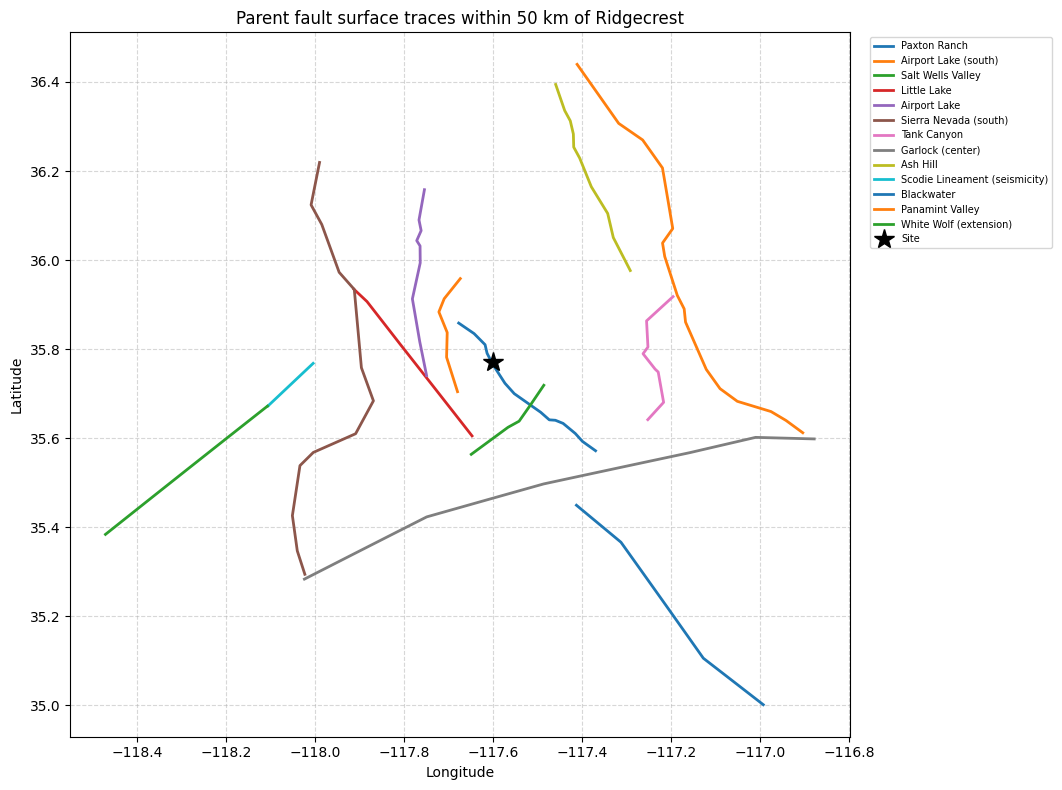

In [11]:
# Plot parent fault surface traces
fig, ax = plt.subplots(figsize=(10, 8))

for pid in sel.parent_ids:
    row = parents.loc[pid]
    xs, ys = row["geometry"].xy
    ax.plot(xs, ys, linewidth=2, label=row["parent_name"])

# Mark the site
ax.plot(-117.60, 35.77, "k*", markersize=15, zorder=5, label="Site")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Parent fault surface traces within 50 km of Ridgecrest")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Subsections

`.subsections` returns all subsections for the selected parents (full extent — not filtered
by radius). Each row has `parent_id`, `dip`, `upper_depth_km`, `lower_depth_km`, `area_km2`,
`geometry`, etc. You can group by `parent_id` to compute your own aggregations (e.g.,
area-weighted dip).

In [12]:
subs = sel.subsections
print(f"{len(subs)} subsections across {subs['parent_id'].nunique()} parents")

# Example: compute area-weighted dip per parent
for pid in sel.parent_ids[:5]:
    group = subs[subs["parent_id"] == pid]
    weights = group["area_km2"]
    wtd_dip = np.average(group["dip"], weights=weights)
    name = parents.loc[pid, "parent_name"]
    print(f"  {name}: {len(group)} subsections, area-wtd dip = {wtd_dip:.1f}°")

115 subsections across 13 parents
  Paxton Ranch: 6 subsections, area-wtd dip = 90.0°
  Airport Lake (south): 4 subsections, area-wtd dip = 50.0°
  Salt Wells Valley: 4 subsections, area-wtd dip = 90.0°
  Little Lake: 7 subsections, area-wtd dip = 90.0°
  Airport Lake: 6 subsections, area-wtd dip = 50.0°


### Ruptures

`.ruptures` returns an enriched GeoDataFrame with one row per rupture (indexed by rupture id).
Each row has `m` (magnitude), `rate`, `depth`, `dip`, `width`, `rake`, `geometry`, `length_km`,
`area_km2`, and `contributions` — a list of `(parent_id, area_pct)` tuples for every parent the
rupture touches, where `area_pct` is that parent's percentage of the rupture's total area (the
percentages sum to 100).

To attribute rates to individual faults, **explode** `contributions` into one row per
(rupture, parent), then multiply `rate * area_pct / 100`.

In [13]:
rups = sel.ruptures
print(f"{len(rups)} ruptures")
print("Columns:", list(rups.columns))
rups[["m", "rate", "length_km", "area_km2", "contributions"]].head(10)

42739 ruptures
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'contributions']


,m,rate,length_km,area_km2,contributions
72,6.51,2.012449e-05,15.706558,266.544916,"[(1, 100.0)]"
73,6.69,4.383015e-05,23.559808,399.816887,"[(1, 100.0)]"
74,6.83,1.055954e-05,31.412992,533.087726,"[(1, 100.0)]"
75,6.94,5.157790e-06,39.269534,666.415568,"[(1, 100.0)]"
76,7.03,9.238737e-05,47.122932,799.690047,"[(1, 100.0)]"
78,6.82,1.640551e-06,34.440386,510.084680,"[(1, 52.25503275236003), (145, 47.744967247639..."
79,7.02,6.849859e-07,49.376996,763.563352,"[(1, 34.90802897980545), (145, 31.895161337262..."
80,7.09,3.020606e-19,56.848163,890.351271,"[(1, 29.937051242776025), (145, 27.35322237479..."
81,7.15,4.719502e-07,64.323714,1017.213566,"[(1, 26.20343704401093), (145, 23.941851675241..."
82,7.26,1.811963e-07,80.033440,1283.812247,"[(1, 41.52815946934225), (145, 18.970045176741..."


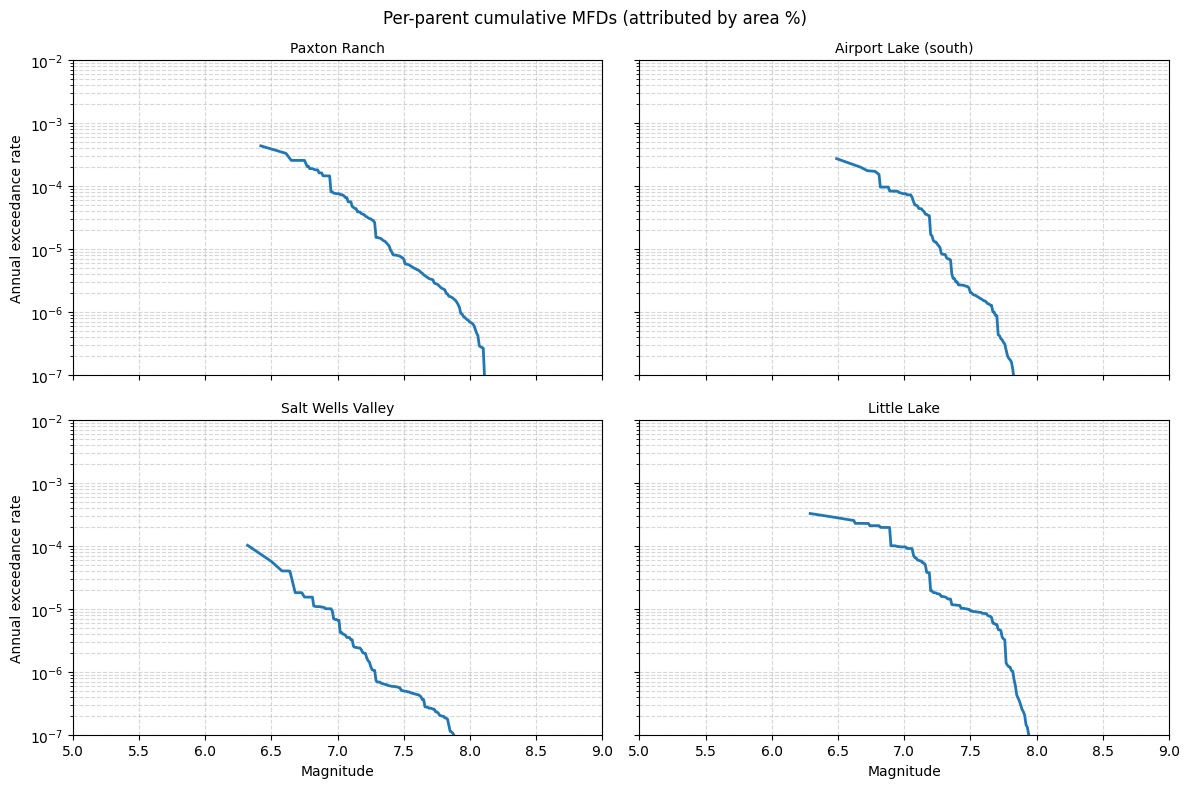

In [14]:
# Example: build per-parent magnitude-rate distributions.
# Explode the per-parent contributions into one row per (rupture, parent), then attribute rate.
exploded = rups.explode("contributions")
exploded[["parent_id", "area_pct"]] = pd.DataFrame(
    exploded["contributions"].tolist(), index=exploded.index
)
exploded["attributed_rate"] = exploded["rate"] * exploded["area_pct"] / 100.0

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
example_pids = sel.parent_ids[:4]

for ax, pid in zip(axes.flat, example_pids):
    parent_rups = exploded[exploded["parent_id"] == pid]
    binned = parent_rups.groupby("m")["attributed_rate"].sum()
    cumulative = binned.sort_index(ascending=False).cumsum().sort_index()
    ax.semilogy(cumulative.index, cumulative.values, linewidth=2)
    ax.set_title(parents.loc[pid, "parent_name"], fontsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.set(xlim=(5, 9), ylim=(1e-7, 1e-2))

axes[1, 0].set_xlabel("Magnitude")
axes[1, 1].set_xlabel("Magnitude")
axes[0, 0].set_ylabel("Annual exceedance rate")
axes[1, 0].set_ylabel("Annual exceedance rate")

fig.suptitle("Per-parent cumulative MFDs (attributed by area %)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. GridSelection

`GridSelection` filters the background gridded seismicity to points within a geodesic
distance of a site. It uses a separate radius from `ParentSelection` to allow the
grid extent to differ from the fault search radius.

In [15]:
gs = GridSelection(ds, lat=35.77, lon=-117.60, dist_km=100)
grid = gs.grid
print(f"{len(grid)} grid points within 100 km")
print("Columns:", list(grid.columns[:6]), "...")
grid[["lon", "lat", "ss_wt", "r_wt", "n_wt", "5.05", "7.85", "dist_km"]].head(10)

312 grid points within 100 km
Columns: ['lon', 'lat', 'ss_wt', 'r_wt', 'n_wt', '5.05'] ...


,lon,lat,ss_wt,r_wt,n_wt,5.05,7.85,dist_km
0,-117.6,35.8,0.5,0.0,0.5,0.001287,3.459760e-09,3.328651
1,-117.6,35.7,0.5,0.0,0.5,0.001007,5.075090e-09,7.766787
2,-117.5,35.8,0.5,0.0,0.5,0.000303,9.978070e-08,9.634084
3,-117.7,35.8,0.5,0.0,0.5,0.000987,5.036740e-09,9.634084
4,-117.5,35.7,0.5,0.0,0.5,0.000451,2.435150e-08,11.923127
5,-117.7,35.7,0.5,0.0,0.5,0.000577,4.274360e-09,11.923127
6,-117.6,35.9,0.5,0.0,0.5,0.000243,7.960200e-09,14.424273
7,-117.5,35.9,0.5,0.0,0.5,0.000153,6.375460e-08,17.020365
8,-117.7,35.9,0.5,0.0,0.5,0.000334,4.150100e-09,17.020365
9,-117.4,35.8,0.5,0.0,0.5,0.000155,5.744290e-08,18.385388
